### This notebook demonstrates the post-analysis and visualisation of the PRAS results

In [1]:
import sys
import os

import calendar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
import time
import datetime as datetime
sys.path.append("src")
import numpy as np
from utility import get_shortfall_data, plot_std_error, load_scenario_data
from utility import load_eue_shortfall, get_all_info, reg_load_gen
from utility import plot_yearly_rlg_v1, seasonal_ppmm_stats,get_data_simu 
from utility import flow_result, plot_flow, plot_EUE_lgs

area_code_region = {1:"NNSW", 2:"CNSW", 3:"SNW", 4:"SNSW", 5:"WNV",
                        6:"MEL", 7:"SEV",  8:"NQ", 9:"CQ", 10:"GG",
                        11:"SQ", 12:"NSA", 13:"CSA", 14:"SESA", 15:"TAS"} 

IDIR = os.path.join(os.getcwd(), "../../../../data/ISP_data", "pras_metrics_output", "shortfall_data")
figsize = (25,10)
mpl.rcParams['font.family'] = 'sans-serif'

In [2]:
def load_shortfall_error_data(scenario, IDIR):
    scen_DIR = os.path.join(IDIR, scenario)
    if scenario == "LT_BASE":
        date_run = "29-Apr-26-7-8-7"
    elif scenario == "LT_BEST":
        date_run = "23-Apr-26-7-42-46"
    elif scenario == "LT_WORST":
        date_run = "23-Apr-26-7-42-43"
    elif scenario == "LT_TYP":
        date_run = "23-Apr-26-7-42-45"
  
    data_file = os.path.join(scen_DIR, date_run, "pras_results.json")
    lole_mean, lole_std, eue_mean, eue_std, neue_mean, neue_std, shortfall_data = get_shortfall_data(data_file, area_code_region)
    error_dict = {"lole_mean":lole_mean, "lole_std":lole_std,
             "eue_mean":eue_mean,"eue_std":eue_std,"neue_mean":neue_mean,
             "neue_std":neue_std,"shortfall_data":shortfall_data}
    return error_dict, shortfall_data
    

In [3]:
scenario = "LT_BASE"
print("Scenario chosen: ", scenario)
error_dict, shortfall_data = load_shortfall_error_data(scenario, IDIR)

Scenario chosen:  LT_BASE


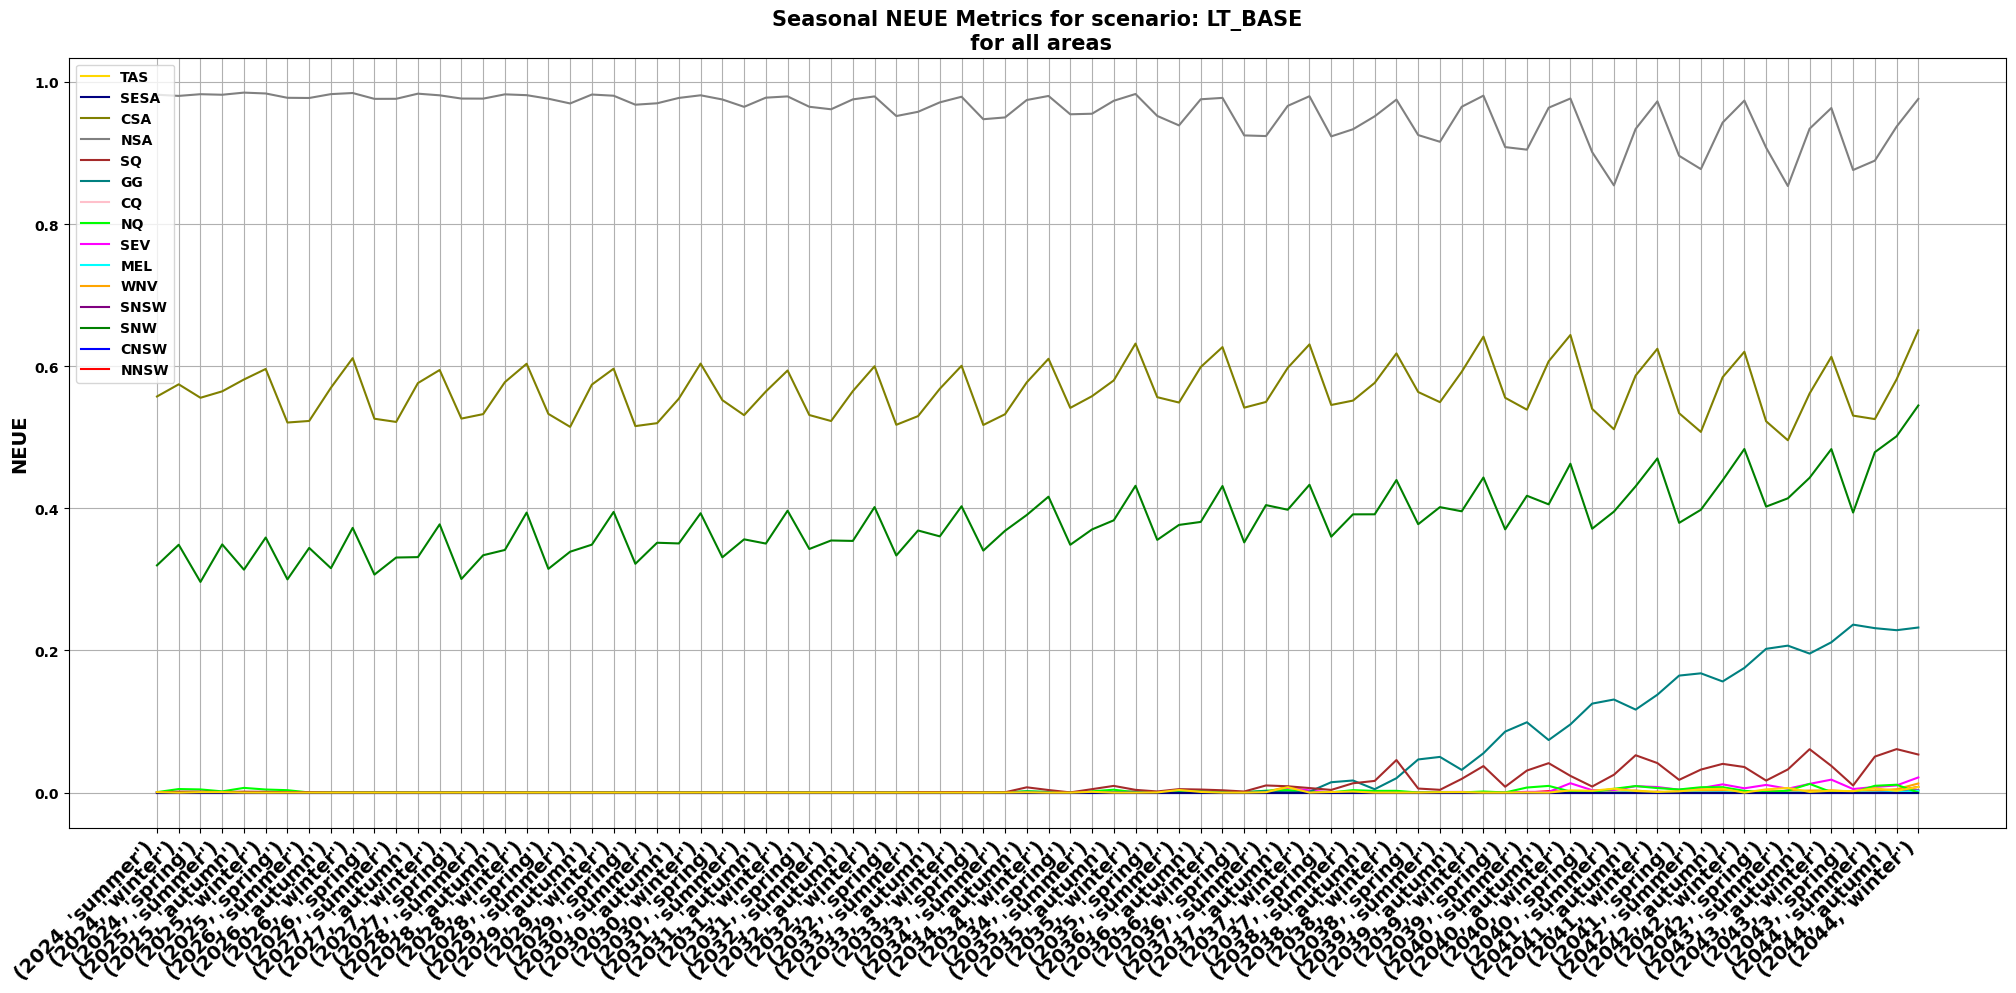

In [4]:
seasonal_data_LT_TYP = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, area=False)
    

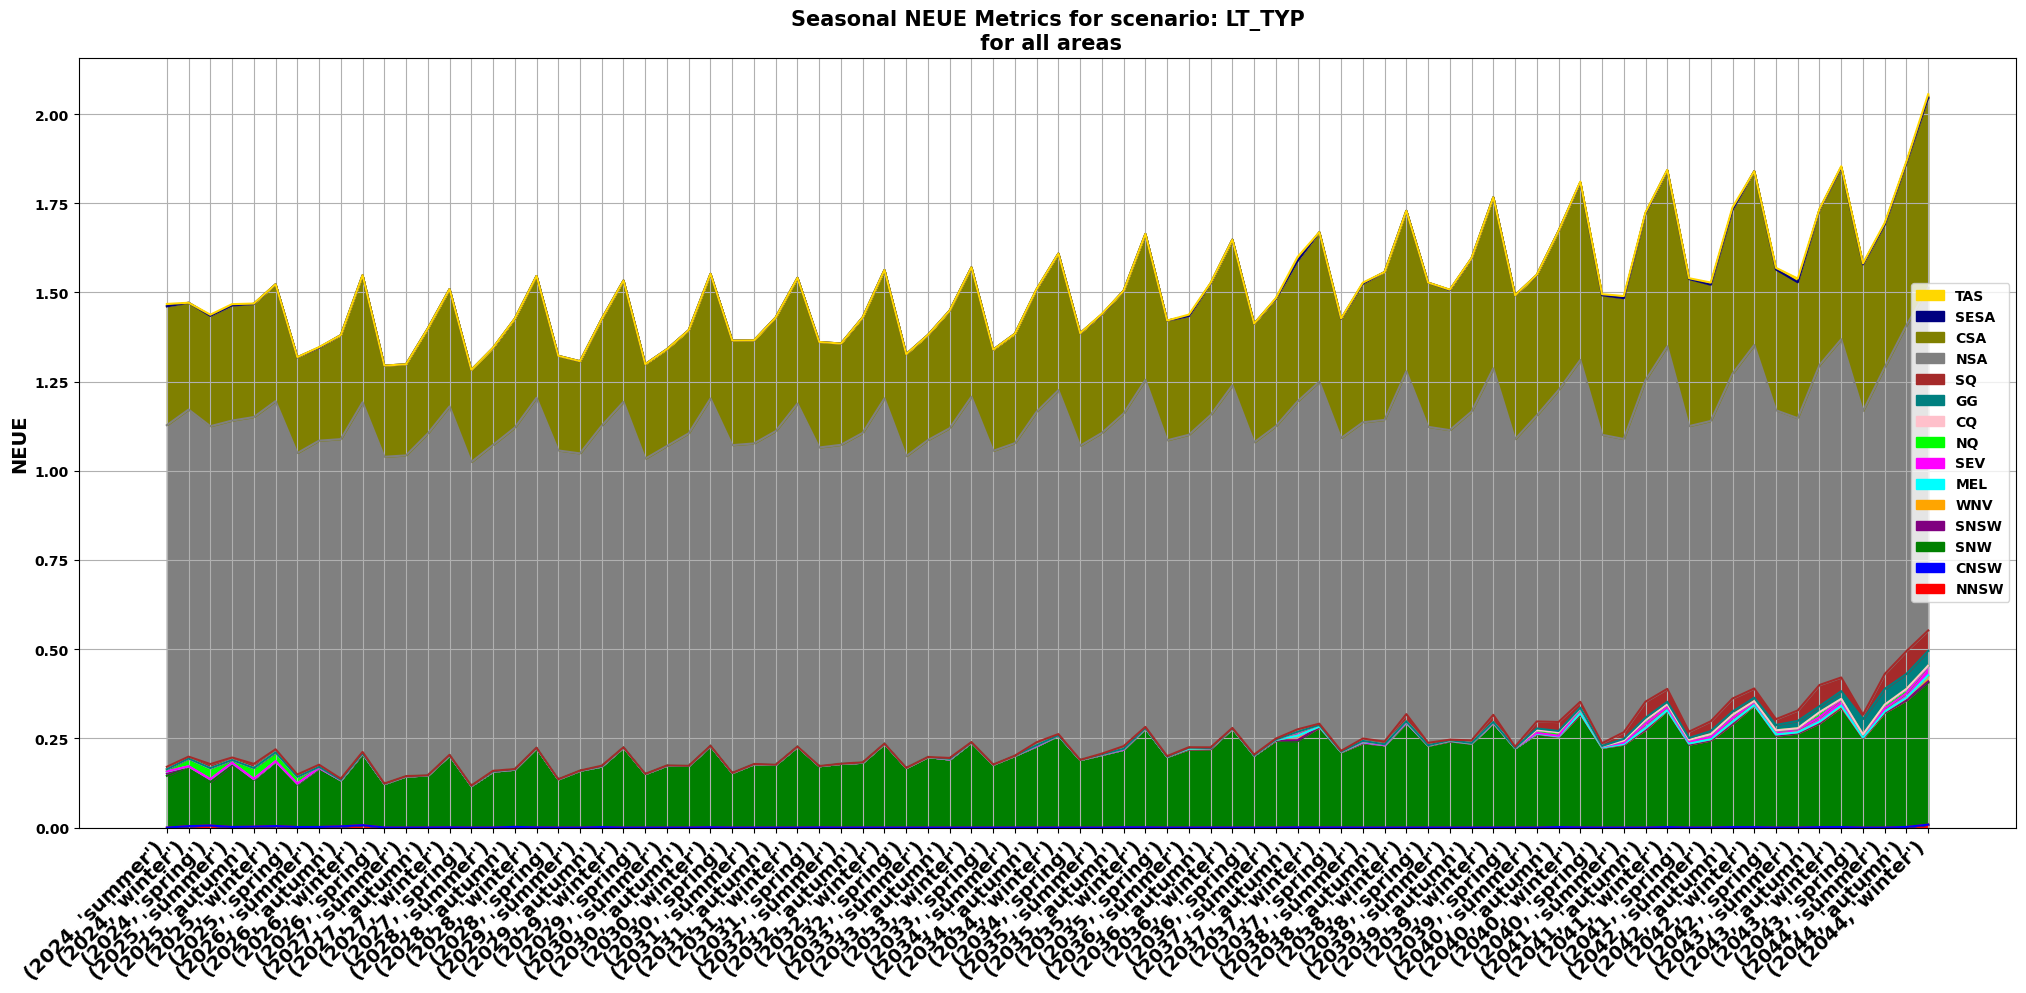

In [75]:
seasonal_data_LT_TYP = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

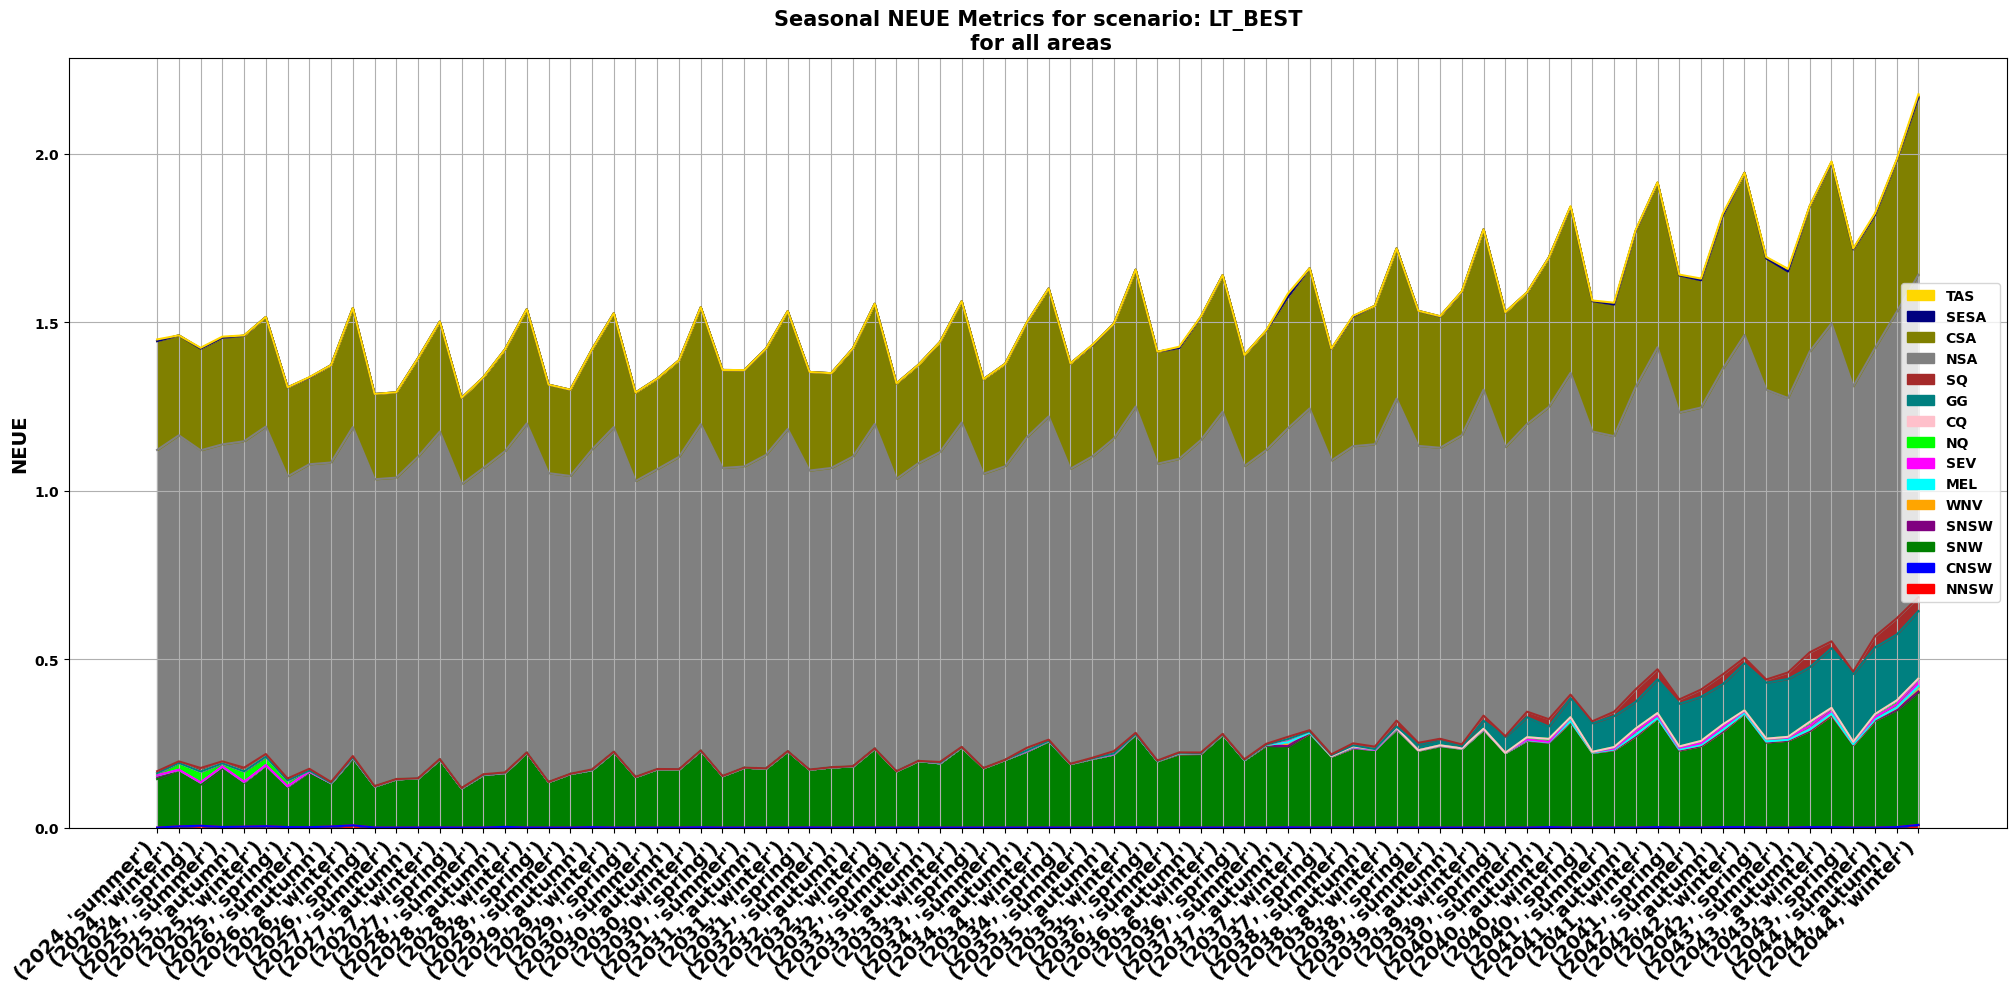

In [72]:
seasonal_data_LT_BEST = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

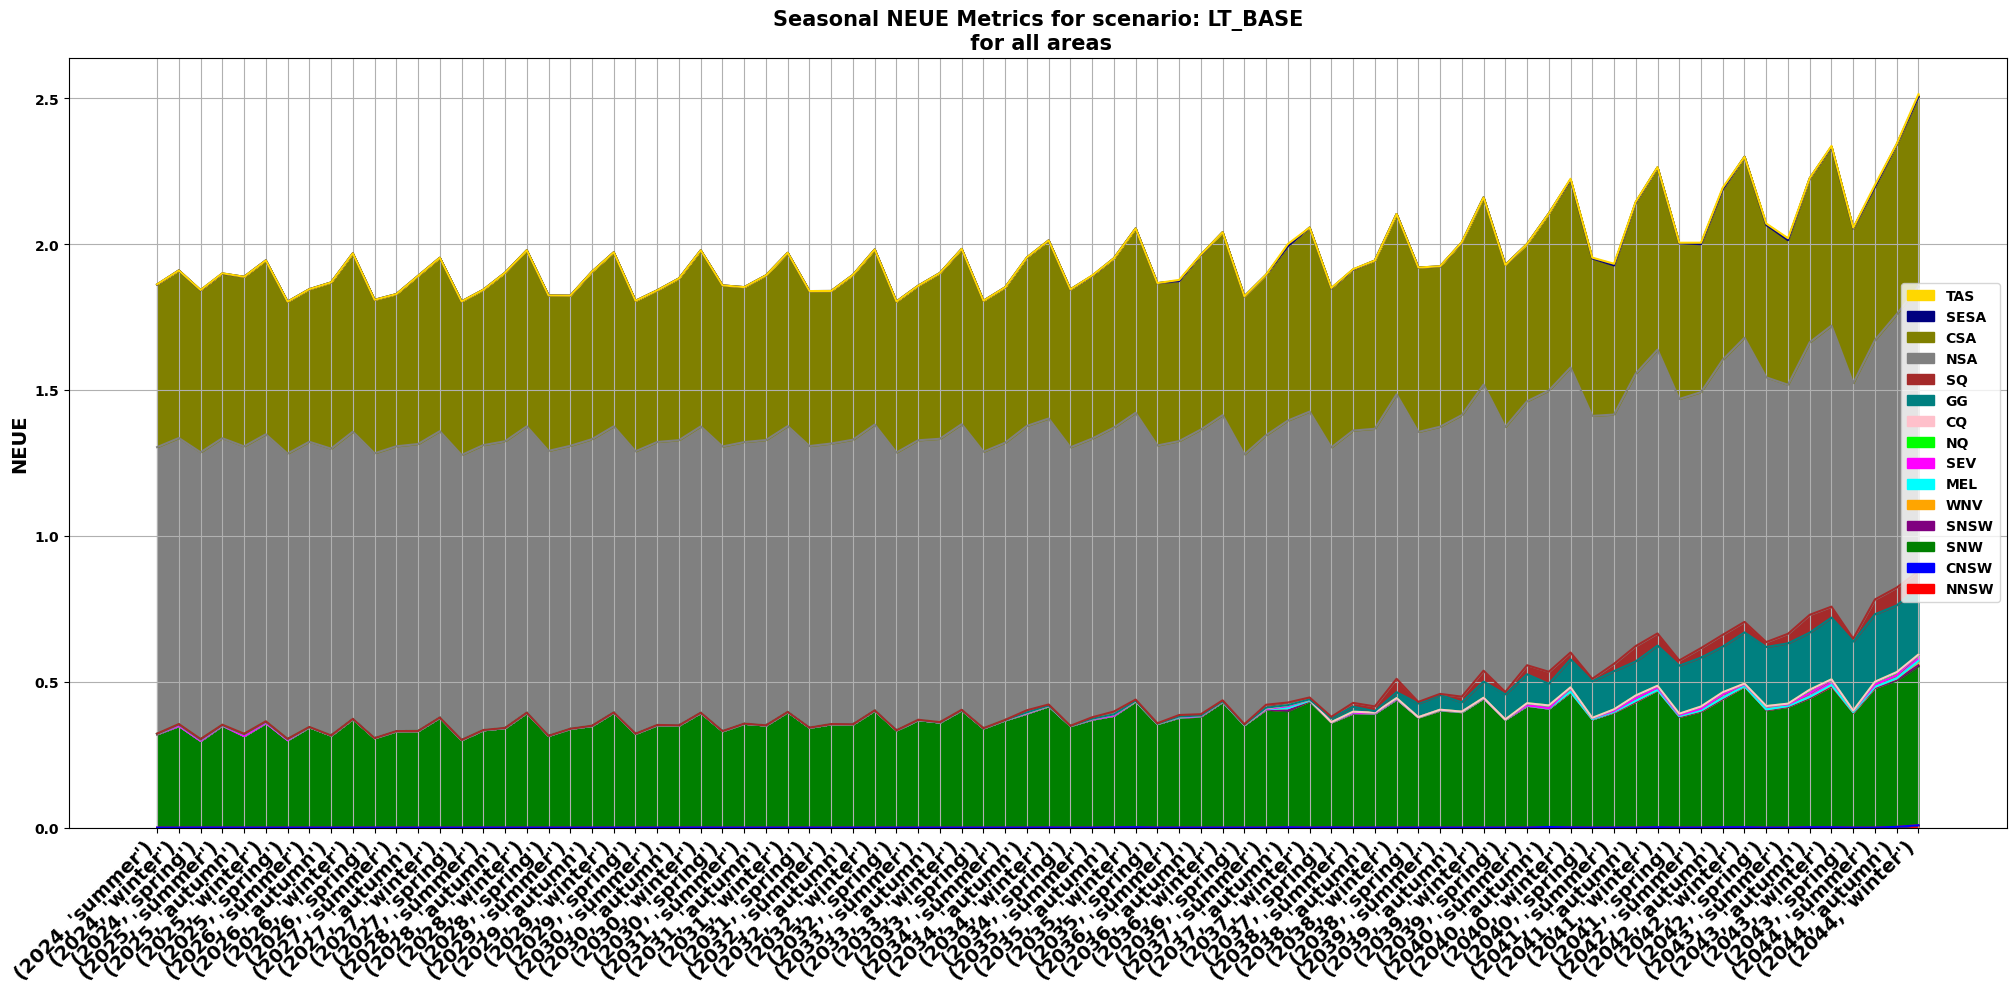

In [167]:
seasonal_data_LT_BASE = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

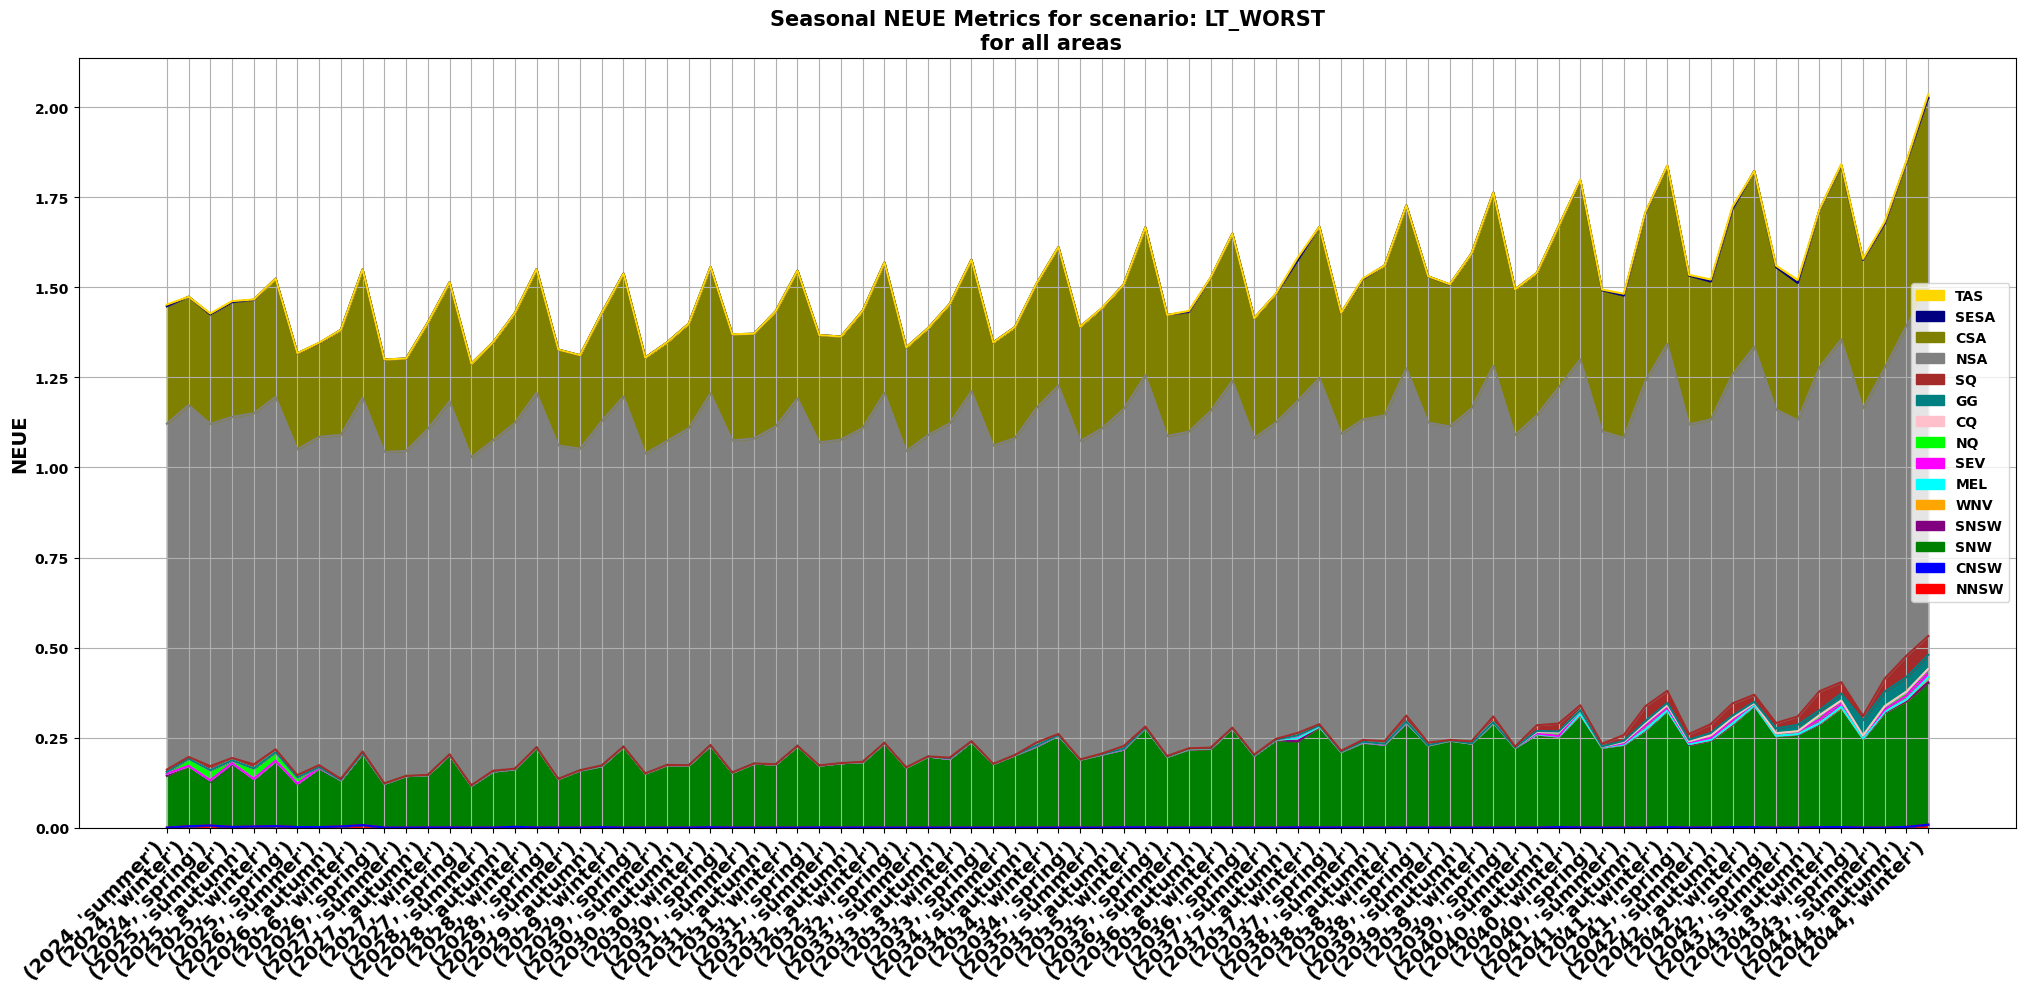

In [68]:
seasonal_data_LT_WORST = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

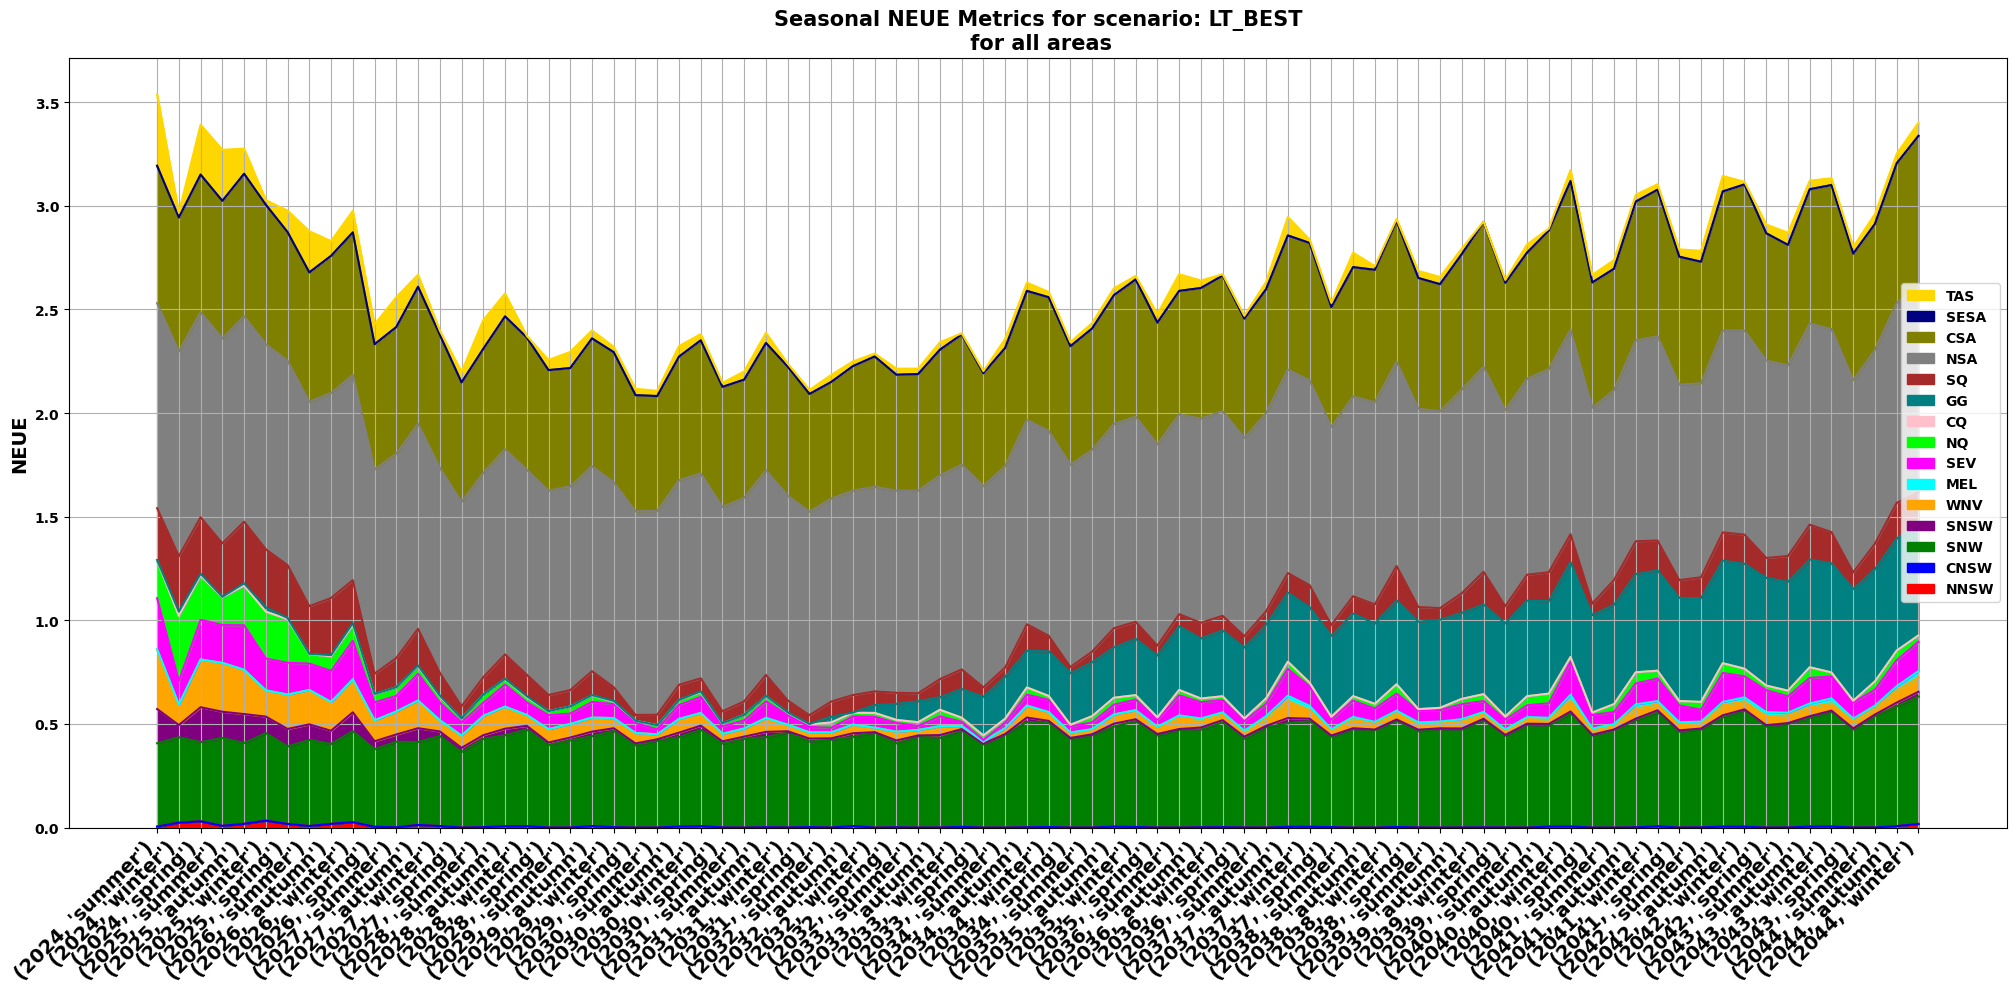

In [9]:
seasonal_data_LT_BEST = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

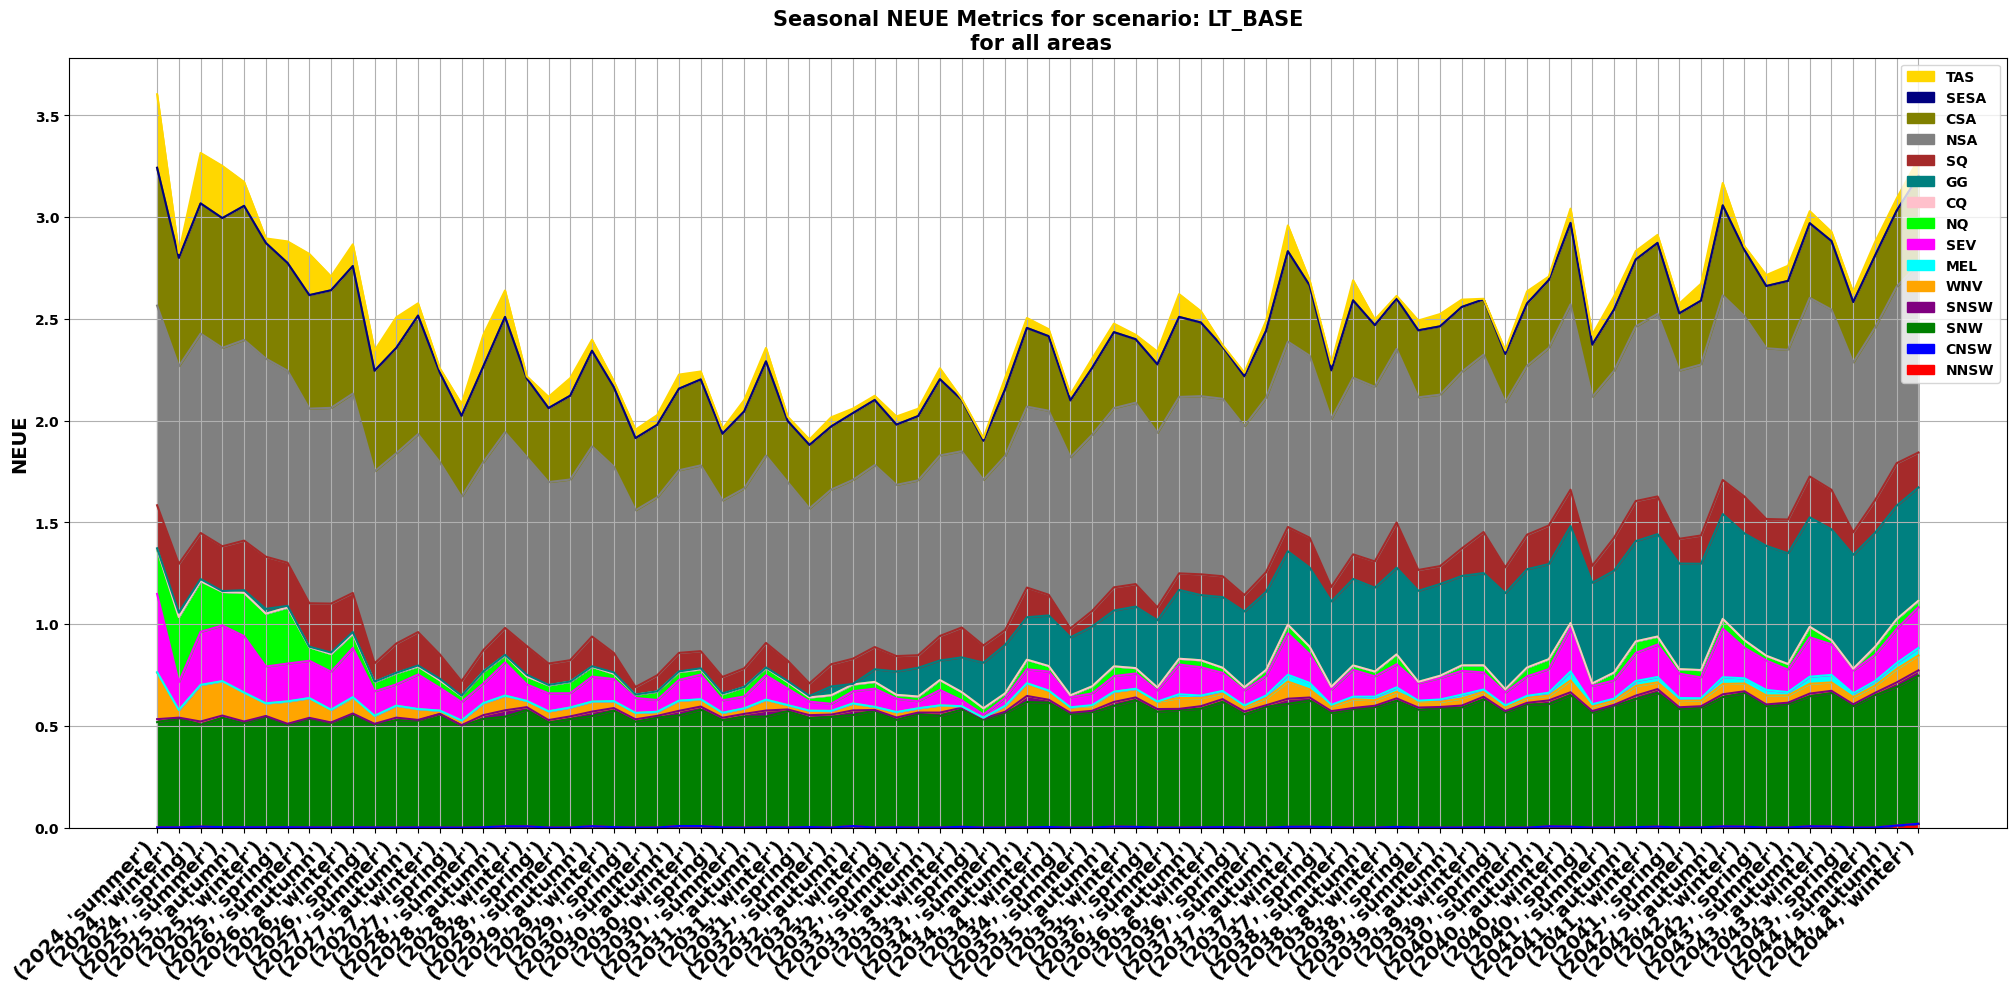

In [7]:
seasonal_data_LT_BASE = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

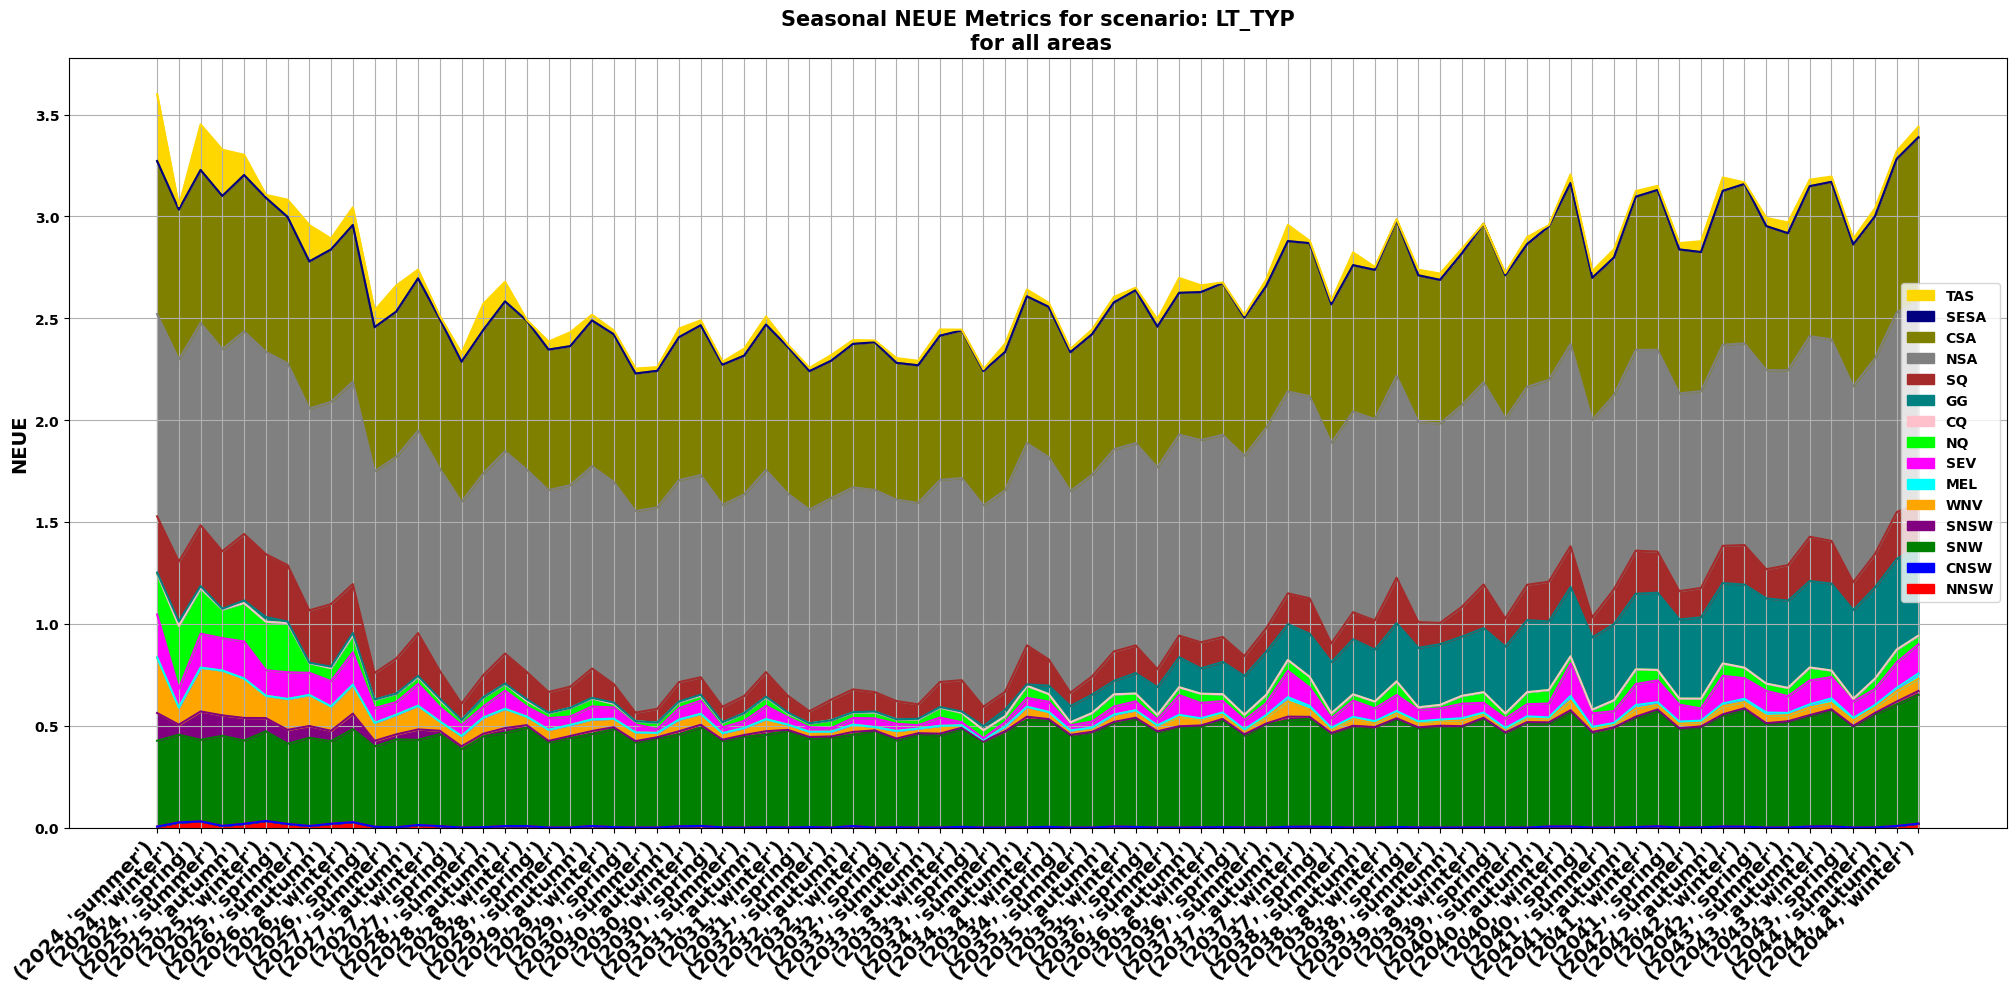

In [4]:
seasonal_data_LT_TYP = seasonal_ppmm_stats(shortfall_data, area_code_region, 
                        scenario, IDIR, figsize)

In [129]:
def plot_diff_baseline(best_baseline, worst_baseline, typ_baseline, area_code_region):
    area_15 = list(area_code_region.values())
    best_baseline_15 = best_baseline[area_15]
    worst_baseline_15 = worst_baseline[area_15]
    typ_baseline_15 = typ_baseline[area_15]
    combined_diff = pd.concat([best_baseline_15.add_prefix('best_'), worst_baseline_15.add_prefix('worst_'), 
                           typ_baseline_15.add_prefix('typical_')], axis=1)
    data = combined_diff.columns.tolist()
    sorted_list = sorted(data, key=lambda x: x.split('_')[1])
    combined_diff = combined_diff[sorted_list]
    fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
# Use a diverging color map (e.g., 'coolwarm' or 'RdBu')
    cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7]) 
    sns.heatmap(combined_diff.T, cmap="RdBu_r", center=0, annot=False, ax=ax1,
           xticklabels=1, yticklabels=1, cbar_ax=cbar_ax)
    ax1.set_xlabel('')
    ax1.set_xticklabels(combined_diff.index.tolist(), fontweight='bold',
                        fontsize=14)
    ax1.set_yticklabels(combined_diff.T.index.tolist(), fontweight='bold',
                        fontsize=10)
#plt.tight_layout()
    fig.suptitle('Best, worst and typical variation in NEUE vs Baseline', weight="bold", fontsize=15)
    plt.show()
    return combined_diff

In [134]:
seasonal_data_LT_BEST[area_15]

NNSW  CNSW       SNW      SNSW       WNV       MEL  \
timestamp season                                                           
2024      summer  0.000027   0.0  0.144112  0.005974  0.004648  0.000000   
          winter  0.003627   0.0  0.167933  0.000106  0.000016  0.000000   
          spring  0.005487   0.0  0.121521  0.005717  0.001085  0.000000   
2025      summer  0.001804   0.0  0.174346  0.003430  0.001677  0.000000   
          autumn  0.002749   0.0  0.130630  0.001848  0.000422  0.000000   
...                    ...   ...       ...       ...       ...       ...   
2043      winter  0.001306   0.0  0.331800  0.000009  0.003229  0.001988   
          spring  0.000000   0.0  0.245345  0.000079  0.001790  0.000228   
2044      summer  0.000000   0.0  0.318155  0.000212  0.002712  0.000175   
          autumn  0.001434   0.0  0.346082  0.002315  0.005332  0.000852   
          winter  0.008182   0.0  0.392569  0.003350  0.013509  0.002669   

                       SEV        NQ   CQ            GG        SQ       NSA  \
timestamp season                                                              
2024      summer  0.000752  0.006075  0.0  1.025873e-07  0.005856  0.953719   
          winter  0.000008  0.020394  0.0  0.000000e+00  0.004628  0.967961   
          spring  0.000443  0.031729  0.0  3.271312e-04  0.010691  0.943107   
2025      summer  0.000434  0.009008  0.0  2.930990e-06  0.006028  0.940999   
          autumn  0.000208  0.031299  0.0  1.508580e-06  0.010816  0.968957   
...                    ...       ...  ...           ...       ...       ...   
2043      winter  0.016471  0.000724  0.0  1.772719e-01  0.020295  0.943812   
          spring  0.006645  0.000365  0.0  2.012205e-01  0.007331  0.846780   
2044      summer  0.006672  0.009051  0.0  1.980360e-01  0.033053  0.855369   
          autumn  0.010083  0.011391  0.0  1.957829e-01  0.048074  0.909656   
          winter  0.022445  0.000072  0.0  2.001197e-01  0.041383  0.957184   

                       CSA  SESA           TAS  
timestamp season                                
2024      summer  0.323115   0.0  5.052245e-03  
          winter  0.296705   0.0  9.772026e-07  
          spring  0.301984   0.0  2.359930e-03  
2025      summer  0.316810   0.0  3.005510e-03  
          autumn  0.313590   0.0  7.398847e-04  
...                    ...   ...           ...  
2043      winter  0.478032   0.0  2.550573e-03  
          spring  0.407025   0.0  2.366856e-03  
2044      summer  0.395584   0.0  4.270512e-03  
          autumn  0.449484   0.0  2.877887e-03  
          winter  0.526928   0.0  8.656679e-03  

[82 rows x 15 columns]

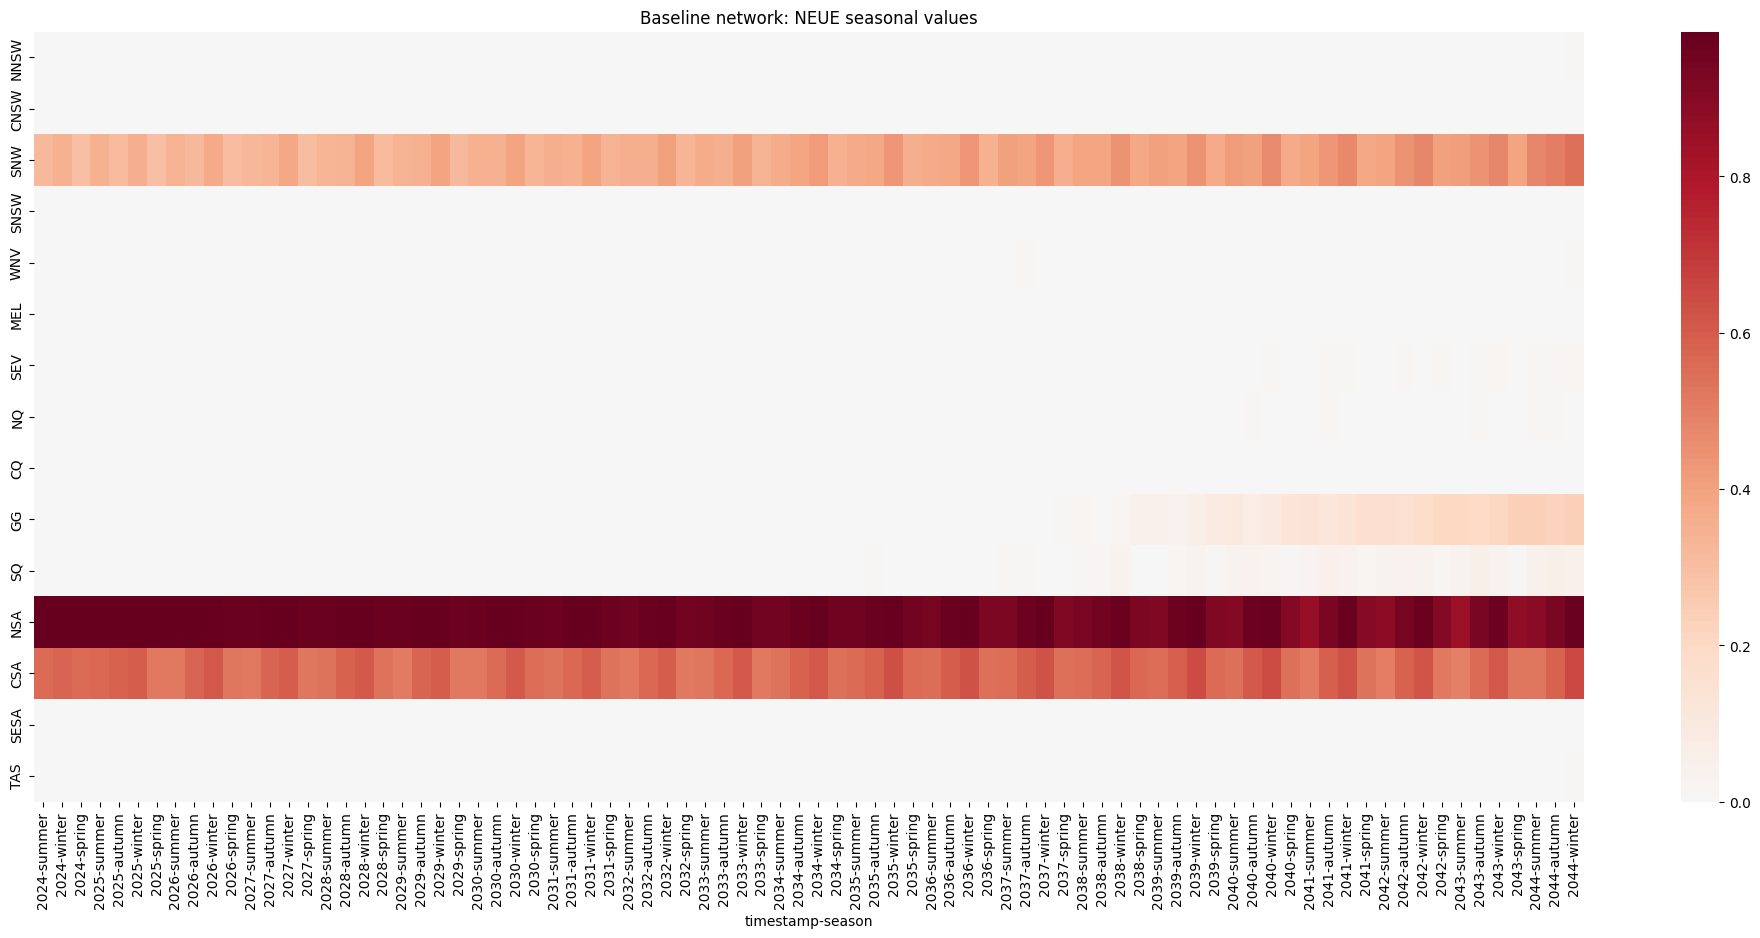

In [171]:

fig, ax1 = plt.subplots(figsize=figsize, nrows=1, ncols=1)
# Use a diverging color map (e.g., 'coolwarm' or 'RdBu')
#cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7]) 
area_15 = list(area_code_region.values())
sns.heatmap(seasonal_data_LT_BASE[area_15].T, cmap="RdBu_r", center=0, annot=False, ax=ax1,
           xticklabels=1, yticklabels=1)
xx = ax1.set_title("Baseline network: NEUE seasonal values")

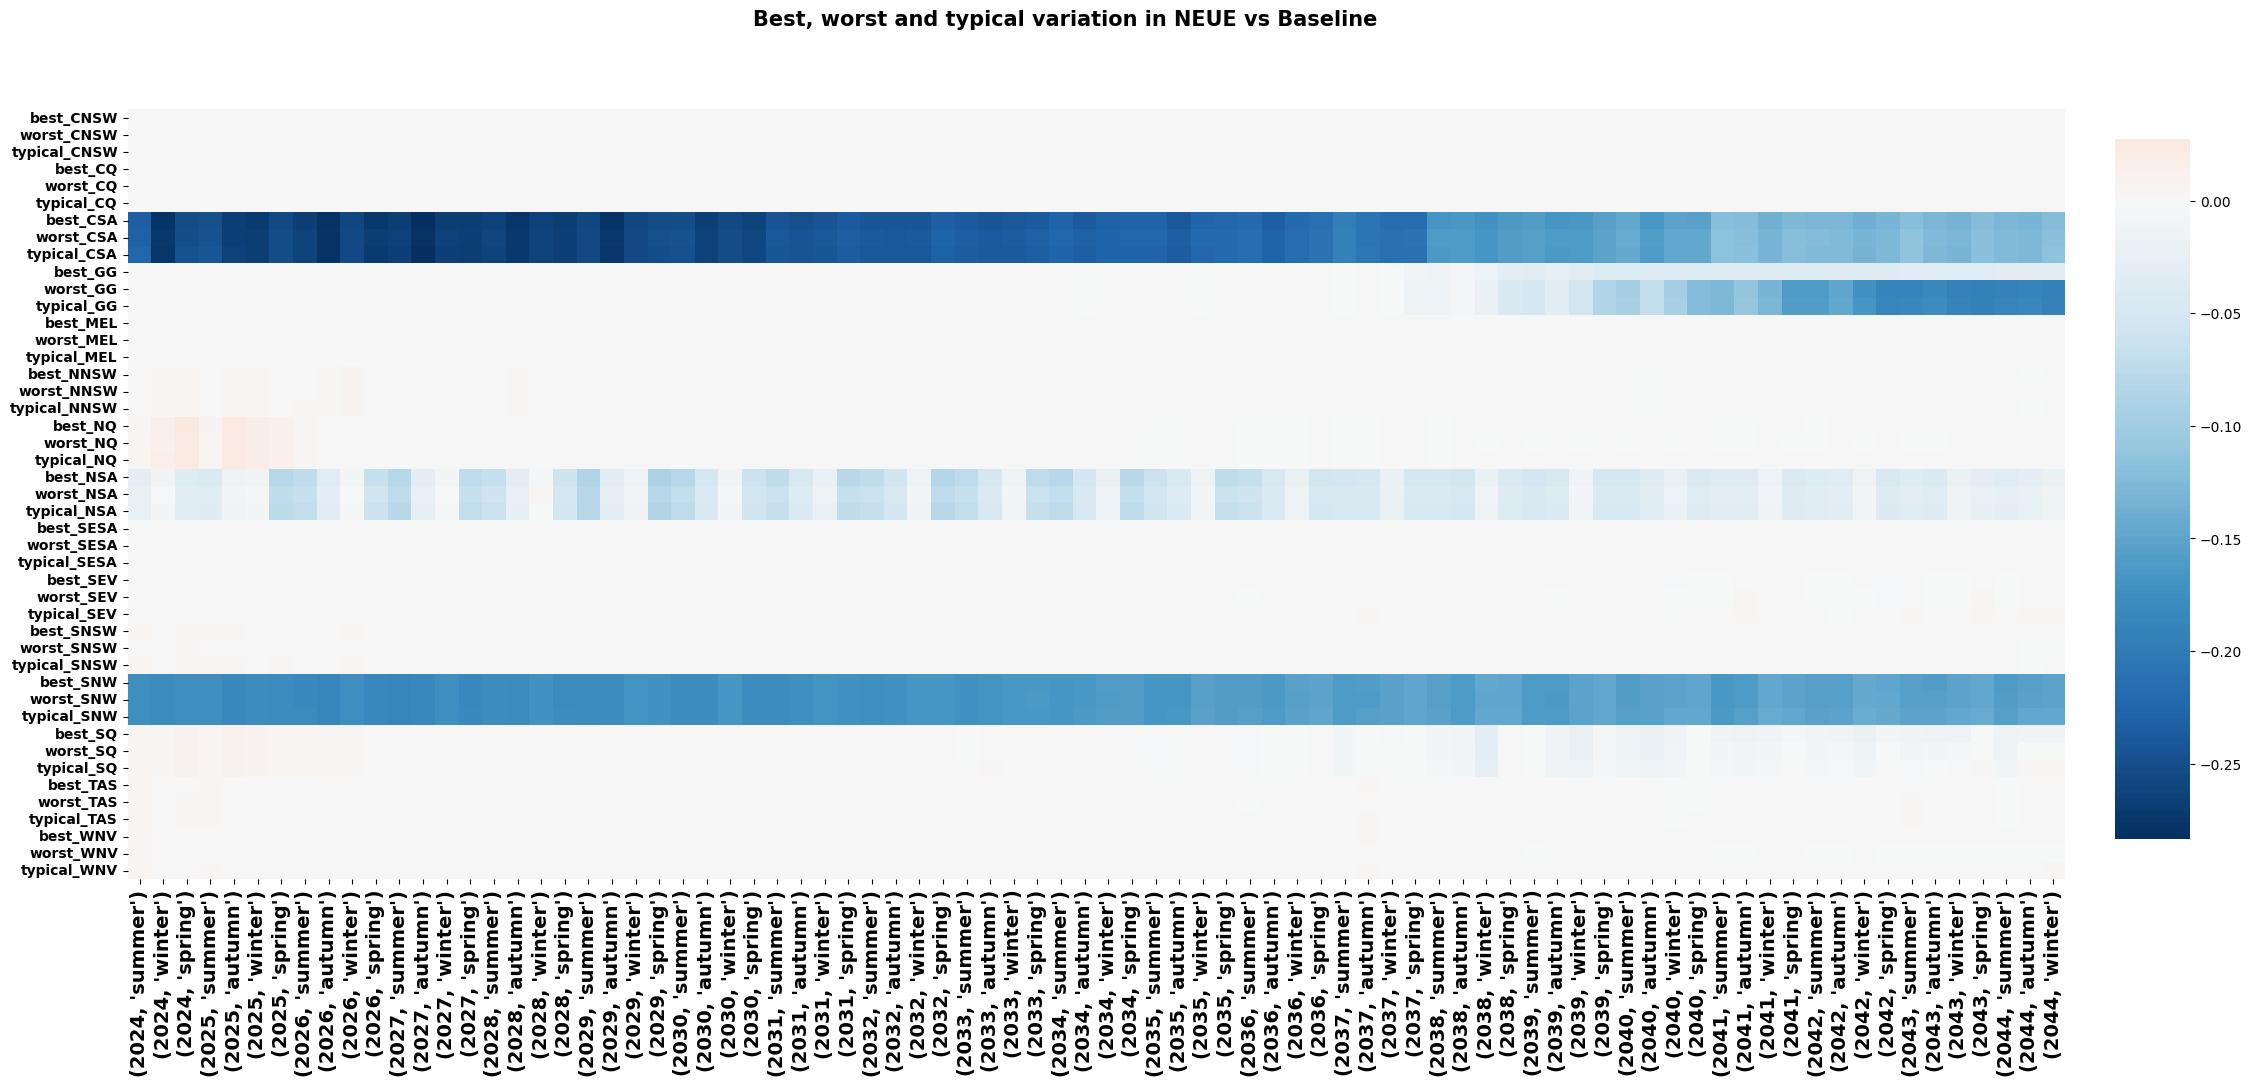

In [168]:
best_baseline =  seasonal_data_LT_BEST - seasonal_data_LT_BASE
worst_baseline = seasonal_data_LT_WORST - seasonal_data_LT_BASE
typ_baseline =  seasonal_data_LT_TYP - seasonal_data_LT_BASE
combined_diff = plot_diff_baseline(best_baseline, worst_baseline, typ_baseline, area_code_region)

In [110]:
y = combined_diff.columns
y = [item for item in y if "_CSA" not in item]
y = [item for item in y if "_NSA" not in item]


scenario:  LT_BASE


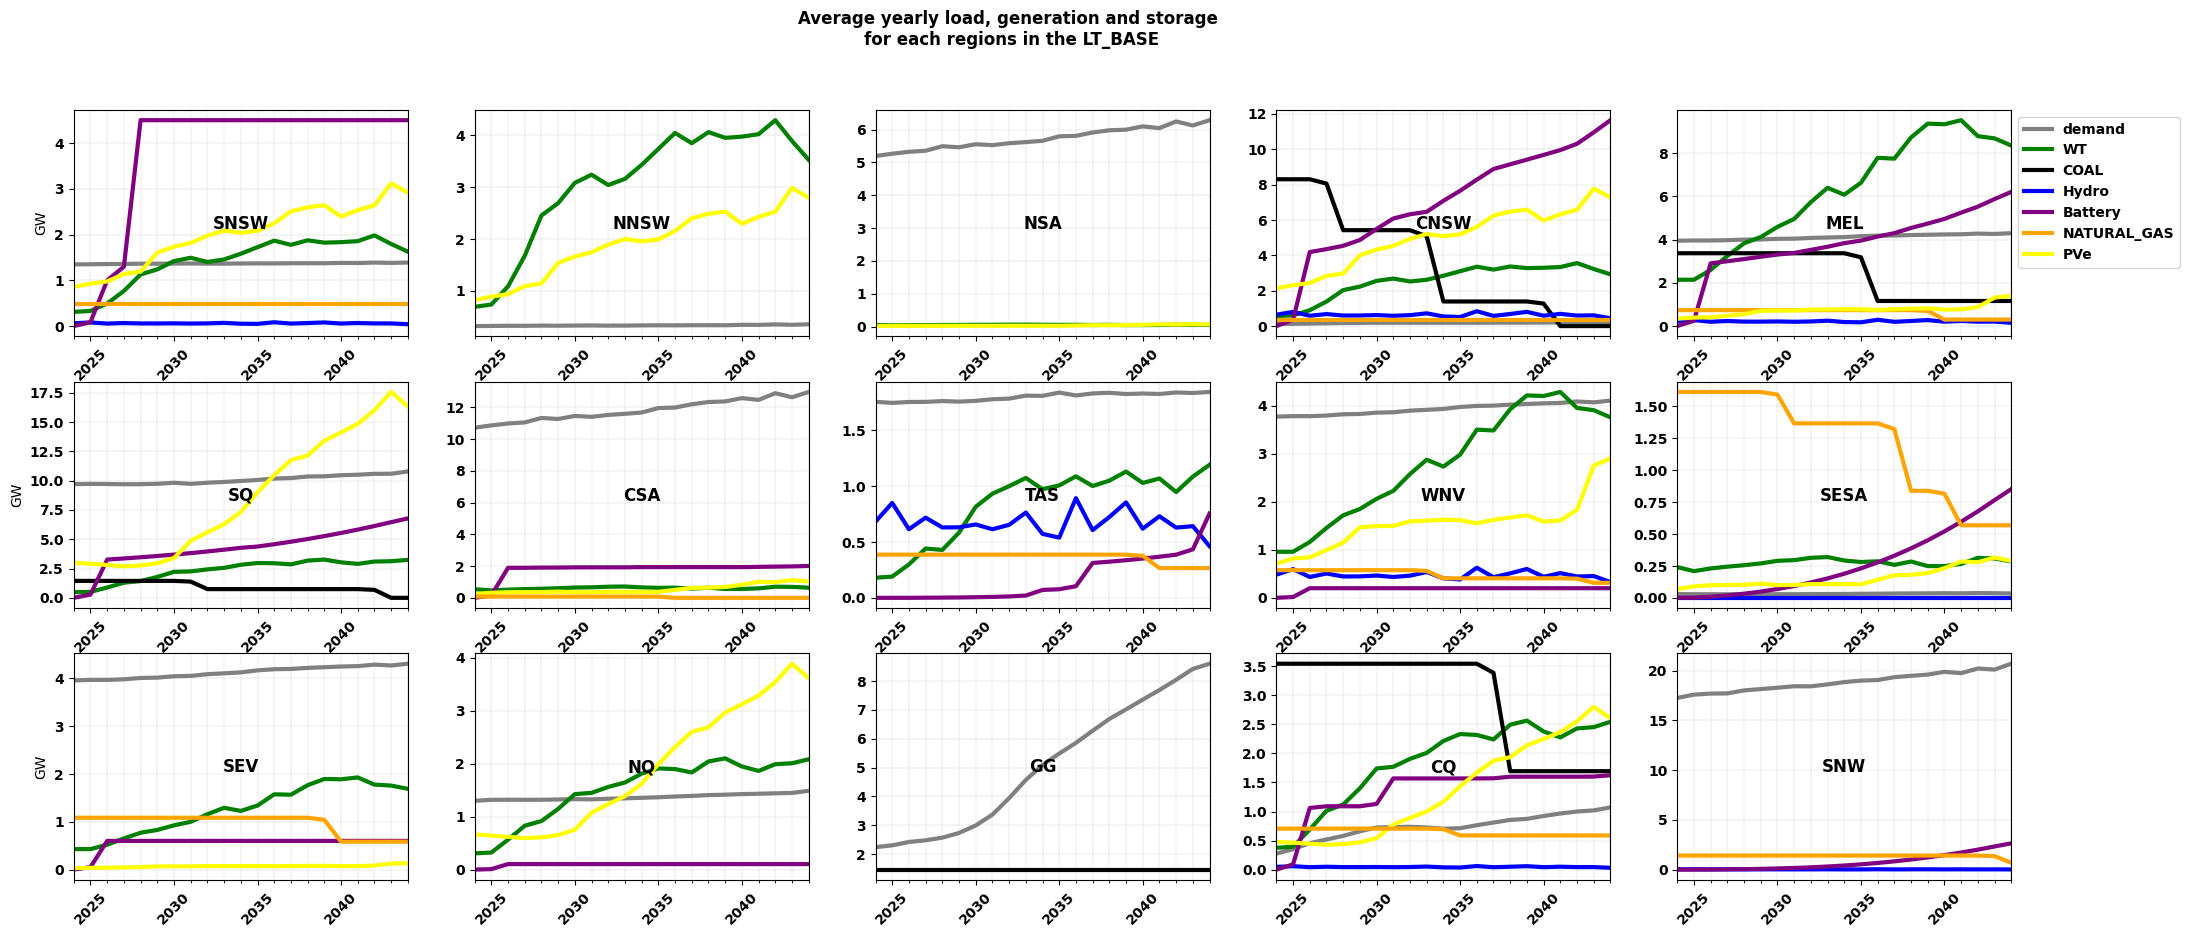

In [48]:
print("scenario: ", scenario)
resample="yearly"
load_gens_simu = get_data_simu(shortfall_data)
plot_yearly_rlg_v1(load_gens_simu, shortfall_data, resample, scenario)

In [141]:
pras_lines = pd.read_csv("../data/output/pras_lines_LT_BEST.csv")
limits_best = pd.read_csv("../data/output/interface_forward_lines_LT_BEST.csv")
limits_best = limits_best.rename(columns={"forward": "best_forward"})

In [144]:
pras_lines = pd.read_csv("../data/output/pras_lines_LT_WORST.csv")
limits_worst = pd.read_csv("../data/output/interface_forward_lines_LT_WORST.csv")
limits_worst = limits_worst.rename(columns={"forward": "worst_forward"})

In [147]:
pras_lines = pd.read_csv("../data/output/pras_lines_LT_TYP.csv")
limits_typ = pd.read_csv("../data/output/interface_forward_lines_LT_TYP.csv")
limits_typ = limits_typ.rename(columns={"forward": "typ_forward"})

In [173]:
all_limits = limits_best.merge(limits_base, on=["region_from", "region_to"], how="left")
all_limits = all_limits.merge(limits_worst, on=["region_from", "region_to"], how="left")
all_limits = all_limits.merge(limits_typ, on=["region_from", "region_to"], how="left")
all_limits["region_from"] = all_limits["region_from"].map(area_code_region)
all_limits["region_to"] = all_limits["region_to"].map(area_code_region)
all_limits

,region_from,region_to,best_forward,base_forward,worst_forward,typ_forward
0,SNSW,CNSW,6861,2861.0,6861.0,6861.0
1,SNSW,WNV,6029,2029.0,6029.0,6029.0
2,NNSW,CNSW,8474,1474.0,17474.0,11474.0
3,NNSW,SQ,3989,1989.0,9089.0,3989.0
4,NSA,CSA,1442,1442.0,1442.0,1442.0
5,CNSW,SNW,9386,6986.0,9386.0,9386.0
6,MEL,TAS,1500,1500.0,1500.0,1500.0
7,MEL,WNV,21823,15823.0,23823.0,21823.0
8,MEL,SEV,13238,13238.0,13238.0,13238.0
9,SQ,GG,180,NaN,NaN,NaN


In [164]:
all_limits = limits_best.merge(limits_base, on=["region_from", "region_to"], how="left")
all_limits = all_limits.merge(limits_worst, on=["region_from", "region_to"], how="left")
all_limits = all_limits.merge(limits_typ, on=["region_from", "region_to"], how="left")
all_limits["region_from"] = all_limits["region_from"].map(area_code_region)
all_limits["region_to"] = all_limits["region_to"].map(area_code_region)
all_limits

,region_from,region_to,best_forward,base_forward,worst_forward,typ_forward
0,SNSW,CNSW,6861,2861.0,6861.0,6861.0
1,SNSW,WNV,6029,2029.0,6029.0,6029.0
2,NNSW,CNSW,8474,1474.0,17474.0,11474.0
3,NNSW,SQ,3989,1989.0,9089.0,3989.0
4,NSA,CSA,1442,1442.0,1442.0,1442.0
5,CNSW,SNW,9386,6986.0,9386.0,9386.0
6,MEL,TAS,1500,1500.0,1500.0,1500.0
7,MEL,WNV,21823,15823.0,23823.0,21823.0
8,MEL,SEV,13238,13238.0,13238.0,13238.0
9,SQ,GG,180,NaN,NaN,NaN


### Get some stats on the pras lines and forward capacity of the interface



In [161]:
pras_lines = pd.read_csv("../data/output/pras_lines_LT_BASE.csv")
limits_base = pd.read_csv("../data/output/interface_forward_lines_LT_BASE.csv")
limits_base = limits_base.rename(columns={"forward": "base_forward"})
#pras_lines

In [155]:
pras_lines[pras_lines.name == "bus_2198-bus_5150-i_connection MARINUS_1"]

,name,ln_type,area_from,area_to,power
84,bus_2198-bus_5150-i_connection MARINUS_1,HVDCLine,6,15,750.0


In [163]:
pras_lines[pras_lines.area_from == 15]

,name,ln_type,area_from,area_to,power
50,bus_2202-bus_5149-i_BASSLINK,HVDCLine,15,7,510.0


In [92]:
pras_lines

,name,ln_type,area_from,area_to,power
0,bus_1189-bus_1289-i_line_1189_to_1469_2_cp,ACLine,2,3,231.0
1,bus_1113-bus_2195-i_line_1113_to_2195_1_cp,ACLine,4,5,677.0
2,bus_2145-bus_2179-i_line_2145_to_2179_1_cp,ACLine,6,5,301.0
3,bus_2199-bus_2202-i_line_2199_to_2202_2_cp,ACLine,6,7,1498.0
4,bus_1110-bus_1140-i_line_1110_to_1511_1_cp,ACLine,2,3,877.0
...,...,...,...,...,...
93,bus_3607-bus_3624-i_line_3607_to_3624_2_cp,ACLine,10,9,676.0
94,bus_2105-bus_2106-i_connection V2_1,ACLine,6,5,1520.0
95,bus_1148-bus_2191-i_line_1148_to_2191_1_cp,ACLine,4,5,707.0
96,bus_1289-bus_1478-i_line_1391_to_1478_1_cp,ACLine,2,3,176.0
